In [1]:
import sys, json
from pathlib import Path
from typing import Dict, Iterable, List, Optional
import pandas as pd
from torch.utils.data import Dataset
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

## Utils

In [2]:
#data utils
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from typing import Dict, Iterable, List, Optional
import pandas as pd
from torch.utils.data import Dataset
import torch
import numpy as np


def split_scale(df, target_cols='y', test_size=0.15, val_size=0.15, scale=True):
    """Split into train/val/test and selectively scale features with StandardScaler."""
    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    # --- Ensure target_cols is iterable ---
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    n = len(df)
    test_start = int(n * (1 - test_size))
    val_start = int(n * (1 - val_size - test_size))

    # --- Define feature columns ---
    feature_cols = [c for c in df.columns if c not in target_cols]

    # --- Exclude raw OHLC, ATR, and boolean/binary columns from scaling ---
    exclude_cols = ['open', 'high', 'low', 'close', 'atr_14']

    # Detect binary/boolean columns automatically
    binary_cols = [c for c in feature_cols if df[c].nunique(dropna=True) <= 2]

    # Form final list of scaled columns
    scale_cols = [
        c for c in feature_cols if c not in exclude_cols + binary_cols]

    print(f"[INFO] Using StandardScaler, scaling = {scale}")
    print(
        f"[INFO] Total features: {len(feature_cols)} | Scaled: {len(scale_cols)} | Excluded: {exclude_cols}")

    scaler = StandardScaler() if scale else None

    if scale:
        # Fit only on training part
        scaler.fit(df[scale_cols].iloc[:test_start])
        df[scale_cols] = scaler.transform(df[scale_cols])
        print(f"[OK] Standard scaling applied to {len(scale_cols)} columns.")
    else:
        print("[INFO] Scaling skipped (using raw features).")

    # --- Split dataset ---
    train_df = df.iloc[:val_start].reset_index(drop=True)
    val_df = df.iloc[val_start:test_start].reset_index(drop=True)
    test_df = df.iloc[test_start:].reset_index(drop=True)

    print(
        f"[OK] Split complete → Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    return train_df, val_df, test_df, scaler


class CryptoDataset(Dataset):
    def __init__(self, df: pd.DataFrame, window_size=64, target='target'):

        self.window_size = window_size
        self.features = torch.as_tensor(
            df.drop(columns=target).to_numpy(), dtype=torch.float32)
        self.targets = torch.as_tensor(
            df[target].to_numpy(), dtype=torch.float32)

    def __len__(self):
        return len(self.features) - self.window_size + 1

    def __getitem__(self, idx):
        X = self.features[idx: idx + self.window_size]
        y = self.targets[idx + self.window_size - 1]
        return X, y


def triple_barrier_label(df, close='close', high='high', low='low', volatility='atr_14', ku=1.5, kd=1.5, hold=16, labels=None, debug=False):
    """
    df: DataFrame with columns close/high/low/volatility (15m bars)
    ku, kd: upper/lower multipliers 
    hold: max holding period in bars
    returns: labels 
    """
    closes, highs, lows, volatility = df[close].values, df[high].values, df[low].values, df[volatility].values

    if labels is None:
        labels = {'higher': 2, 'lower': 1, 'none': 0}

    n = len(df)
    y = np.zeros(n, dtype=int)
    b_up = closes + ku * volatility
    b_dn = closes - kd * volatility

    hit = False

    for i in range(n - hold):
        j = 1
        # barriers in price space, adapted by side
        while not hit and (j <= hold):
            if highs[i+j] >= b_up[i]:
                hit = True
                y[i] = labels['higher']
            elif lows[i+j] <= b_dn[i]:
                hit = True
                y[i] = labels['lower']
            j += 1

        if not hit:
            # expiry label
            y[i] = labels['none']
        hit = False

    out = df.copy()
    out['y'] = y
    if debug:
        out['b_up'] = b_up
        out['b_dn'] = b_dn

    return out.iloc[:n - hold]


def min_max_label(df, close='close', high='high', low='low', horizon=16):
    """
    df: DataFrame with columns close/high/low (15m bars)
    horizon: look-ahead horizon in bars
    returns: Max and Min values within horizon    
    """
    closes, highs, lows = df[close].values, df[high].values, df[low].values

    n = len(df)
    y_high = np.zeros(n, dtype=float)
    y_low = np.zeros(n, dtype=float)

    for i in range(n - horizon):
        y_high[i] = np.max(np.append(highs[i+1:i+1+horizon], closes[i]))
        y_low[i] = np.min(np.append(lows[i+1:i+1+horizon], closes[i]))

    out = df.copy()
    out['y_high'] = np.log(y_high/closes)
    out['y_low'] = -np.log(y_low/closes)

    return out.iloc[:n - horizon]

In [3]:
#DL models

from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union

import matplotlib.pyplot as plt
import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight


ArrayLike = Union[Sequence[float], Sequence[Sequence[float]], Tensor]


def _select_device() -> Tuple[torch.device, bool]:
    if torch.cuda.is_available():
        count = torch.cuda.device_count()
        return torch.device("cuda"), count > 1

    return torch.device("cpu"), False


def _ensure_dir(path: Union[str, Path]) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


class _RNNClassifier(nn.Module):
    def __init__(
        self,
        *,
        input_size,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        dropout: float,
        bidirectional: bool,
        rnn_type: str,
    ) -> None:
        super().__init__()
        rnn_cls = {"lstm": nn.LSTM, "gru": nn.GRU}[rnn_type]
        self.rnn = rnn_cls(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional,
        )
        self.dropout = nn.Dropout(dropout)
        # self.fc = nn.Linear(
        #     hidden_size * (2 if bidirectional else 1), num_classes*4)
        # self.fc2 = nn.Linear(num_classes*4, num_classes*2)
        self.out = nn.Linear(
            hidden_size * (2 if bidirectional else 1), num_classes)

    def forward(self, inputs: Tensor) -> Tensor:
        outputs, _ = self.rnn(inputs)
        last_timestep = outputs[:, -1, :]
        out = self.dropout(last_timestep)
        # out = self.fc(out)
        # out = torch.relu(out)
        # out = torch.relu(self.fc2(out))
        out = self.out(out)

        return out


class _SequenceClassifier:
    def __init__(
        self,
        *,
        input_size,
        hidden_size: int,
        num_layers: int,
        num_classes: int,
        dropout: float,
        bidirectional: bool,
        rnn_type: str,
    ) -> None:
        device, use_parallel = _select_device()
        self.num_classes = num_classes
        model = _RNNClassifier(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=dropout,
            bidirectional=bidirectional,
            rnn_type=rnn_type,
        )
        if use_parallel:
            model = nn.DataParallel(model)
        self.model = model.to(device)
        self.device = device

    # ------------------------------------------------------------------ training
    def train(
        self,
        train_data: Tuple[ArrayLike, Sequence[int]],
        val_data: Tuple[ArrayLike, Sequence[int]],
        *,
        epochs: int = 50,
        batch_size: int = 64,
        lr: float = 1e-3,
        patience: int = 5,
        model_path: Union[str, Path] = "artifacts/sequence_model.pt",
        loss_plot_path: Union[str, Path] = "artifacts/loss_curve.png",
        num_workers: int = 0,
        weights: Optional[ArrayLike] = None,
    ) -> dict:

        if weights is None:
            weights = np.ones(self.num_classes, dtype=np.float32)

        weights = torch.tensor(
            weights, device=self.device, dtype=torch.float32)

        train_loader = DataLoader(
            train_data,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
        )
        val_loader = DataLoader(
            val_data,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
        )

        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        best_val = float("inf")
        best_state: Optional[dict] = None
        bad_epochs = 0
        train_losses: List[float] = []
        val_losses: List[float] = []

        for epoch in range(1, epochs + 1):
            self.model.train()
            running_loss = 0.0
            sample_count = 0
            for features, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
                features = features.to(self.device)
                labels = labels.view(-1).long()
                labels = labels.to(self.device)
                optimizer.zero_grad()
                preds = self.model(features)
                # print(preds.shape, labels.shape)
                loss = criterion(preds, labels)
                loss.backward()
                optimizer.step()
                batch = labels.size(0)
                running_loss += loss.item() * batch
                sample_count += batch

            train_loss = running_loss / max(sample_count, 1)
            val_loss = self._evaluate(val_loader, criterion)
            train_losses.append(train_loss)
            val_losses.append(val_loss)

            if val_loss < best_val - 1e-6:
                best_val = val_loss
                bad_epochs = 0
                best_state = self._state_dict()
                torch.save(best_state, _ensure_dir(model_path))
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    break

        if best_state is not None:
            self._load_state_dict(best_state)

        self._plot_losses(train_losses, val_losses, loss_plot_path)

        return {
            "train_losses": train_losses,
            "val_losses": val_losses,
            "best_val_loss": best_val,
            "epochs_trained": len(train_losses),
            "model_path": str(model_path),
            "loss_plot_path": str(loss_plot_path),
        }

    def _evaluate(self, loader: DataLoader, criterion: nn.Module) -> float:
        self.model.eval()
        total = 0.0
        count = 0
        with torch.no_grad():
            for features, labels in loader:
                features = features.to(self.device)
                labels = labels.view(-1).long()
                labels = labels.to(self.device)
                loss = criterion(self.model(features), labels)
                batch = labels.size(0)
                total += loss.item() * batch
                count += batch
        return total / max(count, 1)

    def _state_dict(self) -> dict:
        if isinstance(self.model, nn.DataParallel):
            return self.model.module.state_dict()
        return self.model.state_dict()

    def _load_state_dict(self, state_dict: dict) -> None:
        target = self.model.module if isinstance(
            self.model, nn.DataParallel) else self.model
        target.load_state_dict(state_dict)

    def _plot_losses(
        self,
        train_losses: Sequence[float],
        val_losses: Sequence[float],
        path: Union[str, Path],
    ) -> None:
        path = _ensure_dir(path)
        plt.figure(figsize=(6, 4))
        epochs = range(1, len(train_losses) + 1)
        plt.plot(epochs, train_losses, label="train", marker="o")
        plt.plot(epochs, val_losses, label="val", marker="s")
        plt.xlabel("epoch")
        plt.ylabel("loss")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.savefig(path)
        plt.close()

    # ---------------------------------------------------------------- inference
    def predict(
        self,
        data: ArrayLike,
        *,
        batch_size: int = 128,
    ):

        loader = DataLoader(
            data,
            batch_size=batch_size,
            shuffle=False,
        )

        preds, probas, y_true = [], [], []

        with torch.no_grad():
            for X, y in loader:
                X = X.to(self.device)
                y_true.extend(y.view(-1).cpu().tolist())

                logits = self.model(X)                 # [B, C] logits
                probs = torch.softmax(logits, dim=1)   # [B, C] probs

                probas.extend(probs.cpu().tolist())
                preds.extend(probs.argmax(dim=1).cpu().tolist())

        arr = np.asarray(probas)                       # (N, C)
        cols = [f"p{i}" for i in range(arr.shape[1])]
        df = pd.DataFrame(arr, columns=cols)
        df.insert(0, "prediction", preds)
        df["true"] = np.asarray(y_true).astype(int)

        return df


class LSTMClassifier(_SequenceClassifier):
    def __init__(
        self,
        *,
        input_size,
        hidden_size: int = 128,
        num_layers: int = 2,
        num_classes: int = 3,
        dropout: float = 0.2,
    ) -> None:
        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=dropout,
            bidirectional=False,
            rnn_type="lstm",
        )


class BiLSTMClassifier(_SequenceClassifier):
    def __init__(
        self,
        *,
        input_size,
        hidden_size: int = 128,
        num_layers: int = 2,
        num_classes: int = 3,
        dropout: float = 0.1,
    ) -> None:
        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=dropout,
            bidirectional=True,
            rnn_type="lstm",
        )


class GRUClassifier(_SequenceClassifier):
    def __init__(
        self,
        *,
        input_size,
        hidden_size: int = 128,
        num_layers: int = 2,
        num_classes: int = 3,
        dropout: float = 0.1,
    ) -> None:
        super().__init__(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            num_classes=num_classes,
            dropout=dropout,
            bidirectional=False,
            rnn_type="gru",
        )

In [4]:
def triple_barrier_metrics(cm: np.ndarray):
    """
    cm: 3x3 confusion matrix (rows=true: 0=expiry,1=SL,2=TP; cols=pred)
    Returns precision/recall/F1 for TP (2) and SL (1), plus macro over {TP,SL}.
    """
    cm = np.asarray(cm, dtype=np.float64)
    if cm.shape != (3, 3):
        raise ValueError(
            "cm must be 3x3 with classes [0,1,2] = [expiry, SL, TP].")

    def prf(k: int):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
        return prec, rec, f1

    # Class 2 = TP-first, Class 1 = SL-first
    p_tp, r_tp, f1_tp = prf(2)
    p_sl, r_sl, f1_sl = prf(1)

    macro_precision = (p_tp + p_sl) / 2
    macro_recall = (r_tp + r_sl) / 2
    macro_f1 = (f1_tp + f1_sl) / 2

    return {
        "tp_precision": p_tp, "tp_recall": r_tp, "tp_f1": f1_tp,
        "sl_precision": p_sl, "sl_recall": r_sl, "sl_f1": f1_sl,
        "macro_precision_tp_sl": macro_precision,
        "macro_recall_tp_sl": macro_recall,
        "macro_f1_tp_sl": macro_f1,
    }

In [5]:
#Trade module
from dataclasses import dataclass
from typing import List, Sequence

import numpy as np
import pandas as pd

TRADE_COLUMNS = [
    "open_date",
    "close_date",
    "side",
    "position_size",
    "pnl",
    "return_pct",
    "total_equity",
    "entry_price",
    "exit_price",
    "exit_reason",
]


@dataclass
class TradeRecord:
    """Container for a single completed trade."""

    open_date: object
    close_date: object
    side: str
    pnl: float
    return_pct: float
    total_equity: float
    entry_price: float
    exit_price: float
    exit_reason: str
    position_size: float = 1.0


@dataclass
class TripleBarrierConfig:
    """Configuration parameters for the triple-barrier strategy."""

    tp_distance: float
    sl_distance: float
    holding_period: int
    min_return: float = 0.0


@dataclass
class PredictedRangeConfig:
    """Configuration parameters for the predicted range strategy."""

    holding_period: int
    min_rr: float


class TradingStrategy:
    """Long-only strategy supporting multiple signal generation modes."""

    def __init__(
        self,
        mode: str = "triple_barrier",
        periods_per_year: int = 365 * 24 * 4,
        transaction_cost: float = 0.0,
        slippage: float = 0.0,
        triple_barrier_config: TripleBarrierConfig | None = None,
        predicted_range_config: PredictedRangeConfig | None = None,

    ) -> None:
        if mode not in {"triple_barrier", "predicted_range"}:
            raise ValueError(
                "mode must be 'triple_barrier' or 'predicted_range'")

        self.mode = mode
        self.periods_per_year = periods_per_year
        self.transaction_cost = transaction_cost
        self.slippage = slippage

        if mode == "triple_barrier":
            if triple_barrier_config is None:
                raise ValueError(
                    "triple_barrier_config must be provided for triple_barrier mode"
                )
            if triple_barrier_config.holding_period <= 0:
                raise ValueError(
                    "holding_period must be positive for triple_barrier strategy")
            self.triple_barrier_config = triple_barrier_config
        else:
            if predicted_range_config is None:
                raise ValueError(
                    "predicted_range_config must be provided for predicted_range mode"
                )
            if predicted_range_config.holding_period <= 0:
                raise ValueError(
                    "holding_period must be positive for predicted_range strategy")
            if predicted_range_config.min_rr <= 0:
                raise ValueError(
                    "min_rr must be positive for predicted_range strategy")
            self.predicted_range_config = predicted_range_config

        self.signals: np.ndarray = np.array([])
        self.positions: List[int] = []
        self.returns: List[float] = []
        self.equity_curve: List[float] = []
        self.trade_log: pd.DataFrame = pd.DataFrame(columns=TRADE_COLUMNS)

    def reset(self) -> None:
        """Reset tracked performance series."""

        self.positions = []
        self.returns = []
        self.equity_curve = []
        self.trade_log = pd.DataFrame(columns=TRADE_COLUMNS)

    def generate_signals(
        self,
        predictions: Sequence[float] | pd.DataFrame,
        prices: pd.DataFrame,
        probability_column: str = "p2",
        log_up_column: str = "y_up",
        log_down_column: str = "y_down",
    ) -> dict:
        """Generate entry signals and barrier levels for the configured mode."""

        if predictions.shape[0] != prices.shape[0]:
            raise ValueError(
                "Predictions and prices must have the same length.")

        if self.mode == "triple_barrier":
            probs = predictions[probability_column].to_numpy(dtype=float)
            config = self.triple_barrier_config
            expected_return = probs * \
                (config.tp_distance/config.sl_distance -
                 self.slippage - self.transaction_cost) - 1
            entries = (expected_return >= config.min_return).astype(int)

        elif self.mode == "predicted_range":
            close_prices = prices['close'].to_numpy(dtype=float)
            log_up = predictions[log_up_column].to_numpy(dtype=float)
            log_down = predictions[log_down_column].to_numpy(dtype=float)
            tp_prices = close_prices * np.exp(log_up)
            sl_prices = close_prices * np.exp(-log_down)
            ranges = tp_prices - sl_prices
            sl_prices = sl_prices - ranges * 0.25

            rr = (tp_prices - close_prices) / (close_prices - sl_prices + 1e-8)
            entries = (
                rr >= self.predicted_range_config.min_rr + self.slippage + self.transaction_cost
            ).astype(int)

        return entries

    def backtest(
        self,
        predictions: Sequence[float] | pd.DataFrame,
        prices: Sequence[float] | pd.DataFrame,
        timestamps: Sequence[object] | None = None,
        probability_column: str = "TP_prob",
        log_up_column: str = "y_up",
        log_down_column: str = "y_down",
        atr_column: str = "atr_14",
        equity: float = 1000.0,
        position_size: float = 1.0,
        risk_mode: str = "fixed_size",
        compound: bool = False,
    ) -> dict:
        """Run a backtest using pre-generated prediction outputs."""

        self.initial_equity = equity
        self.compound = compound
        
        if risk_mode not in {"fixed_size", "fixed_risk"}:
            raise ValueError("risk_mode must be 'fixed_size' or 'fixed_risk'")
        close_prices = prices["close"].to_numpy(dtype=float)

        if close_prices.size == 0:
            raise ValueError("Price data cannot be empty.")

        signals = self.generate_signals(predictions, prices, probability_column=probability_column,
                                        log_up_column=log_up_column, log_down_column=log_down_column)

        self.signals = signals
        if self.mode == "predicted_range":
            log_up = predictions[log_up_column].to_numpy(dtype=float)
            log_down = predictions[log_down_column].to_numpy(dtype=float)
            tp_prices = close_prices * np.exp(log_up)
            sl_prices = close_prices * np.exp(-log_down)
            ranges = tp_prices - sl_prices
            sl_prices = sl_prices - ranges * 0.25
        elif self.mode == "triple_barrier":
            atr = prices[atr_column].to_numpy(dtype=float)
            tp_prices = close_prices + self.triple_barrier_config.tp_distance * atr
            sl_prices = close_prices - self.triple_barrier_config.sl_distance * atr

        if timestamps is None:
            timestamps_arr = np.arange(len(close_prices))
        else:
            timestamps_arr = np.asarray(timestamps)
            if timestamps_arr.shape[0] != close_prices.shape[0]:
                raise ValueError(
                    "Timestamps must align with predictions/prices.")

        high_prices = prices["high"].to_numpy(dtype=float)
        low_prices = prices["low"].to_numpy(dtype=float)

        self.reset()
        trade_records: List[TradeRecord] = []
        current_trade: dict | None = None

        holding_period = (
            self.triple_barrier_config.holding_period
            if self.mode == "triple_barrier"
            else self.predicted_range_config.holding_period
        )

        exit_price: float | None = None
        exit_reason: str | None = None

        for i in range(close_prices.shape[0]):
            timestamp = timestamps_arr[i]
            prev_equity = equity
            # print('step ', i+1)

            if current_trade is not None and i > current_trade["entry_index"]:

                if low_prices[i] <= current_trade["stop_price"]:
                    exit_price = current_trade["stop_price"]
                    exit_reason = "stop_loss"
                    # print(
                        # f'sl low_price: {low_prices[i]}, SL: {current_trade["stop_price"]}')
                elif high_prices[i] >= current_trade["target_price"]:
                    exit_price = current_trade["target_price"]
                    exit_reason = "take_profit"
                    # print(
                    #     f'tp high_price: {high_prices[i]}, TP: {current_trade["target_price"]}')
                elif i >= current_trade["expiry_index"]:
                    exit_price = close_prices[i]
                    exit_reason = "expiry"
                    # print(f'expiry close_price: {close_prices[i]}')
                elif i == close_prices.shape[0] - 1:
                    exit_price = close_prices[i]
                    exit_reason = "market_close"
                    # print(f'market_close close_price: {close_prices[i]}')

                if exit_reason is not None and exit_price is not None:
                    equity, record = self._finalize_trade(
                        current_trade,
                        exit_price,
                        timestamp,
                        exit_reason,
                        equity,
                        current_trade["position_size"],
                    )
                    # print(
                    #     f'close trade TP: {current_trade["target_price"]}, SL: {current_trade["stop_price"]}, low_price: {low_prices[i]}, high_price: {high_prices[i]}, exit_reason: {exit_reason}')
                    trade_records.append(record)
                    current_trade = None
                    exit_price = None
                    exit_reason = None

            if current_trade is None and self.signals[i] == 1 and i < close_prices.shape[0] - 1:
                entry_price = close_prices[i]
                target_price = float(tp_prices[i])
                stop_price = float(sl_prices[i])
                expiry_index = i + holding_period
                if risk_mode == "fixed_size":
                    cur_position_size = position_size
                elif risk_mode == "fixed_risk":
                    cur_position_size = position_size / \
                    (np.abs(stop_price/entry_price - 1) +
                     self.slippage + self.transaction_cost)

                current_trade = {
                    "open_date": timestamp,
                    "entry_price": entry_price,
                    "target_price": target_price,
                    "stop_price": stop_price,
                    "expiry_index": expiry_index,
                    "entry_index": i,
                    "entry_equity": equity,
                    "position_size": cur_position_size
                }
                # print(
                #     f'open trade TP: {current_trade["target_price"]}, SL: {current_trade["stop_price"]}')

            step_return = (equity - prev_equity) / \
                prev_equity if prev_equity else 0.0
            self.returns.append(step_return)
            self.equity_curve.append(equity)
            self.positions.append(1 if current_trade is not None else 0)

        if trade_records:
            self.trade_log = pd.DataFrame(
                [record.__dict__ for record in trade_records], columns=TRADE_COLUMNS
            )
        else:
            self.trade_log = pd.DataFrame(columns=TRADE_COLUMNS)

        return self.calculate_metrics()

    def _finalize_trade(
        self,
        trade: dict,
        exit_price: float,
        close_timestamp: object,
        exit_reason: str,
        equity: float,
        position_size: float = 1.0,
    ) -> tuple[float, TradeRecord]:
        """Close an active trade and return the updated equity and trade record."""

        entry_equity = trade["entry_equity"]
        entry_price = trade["entry_price"]

        gross_return = (exit_price / entry_price - 1.0 -
                        self.slippage - self.transaction_cost) * position_size
        
        if self.compound:
            equity *= (1 + gross_return)
            position_size = position_size*equity
        else:
            equity += self.initial_equity * gross_return
            position_size = position_size*self.initial_equity

        pnl = equity - entry_equity
        return_pct = (equity / entry_equity - 1) * 100 if entry_equity else 0.0

        record = TradeRecord(
            open_date=trade["open_date"],
            close_date=close_timestamp,
            side="long",
            pnl=pnl,
            return_pct=return_pct,
            total_equity=equity,
            entry_price=entry_price,
            exit_price=exit_price,
            exit_reason=exit_reason,
            position_size=position_size
        )

        return equity, record

    def calculate_metrics(self) -> dict:
        """Calculate and return backtest performance metrics."""

        equity_array = np.asarray(self.equity_curve, dtype=float)
        returns_array = np.asarray(self.returns, dtype=float)

        if returns_array.size > 1:
            returns_std = returns_array.std(ddof=1)
        elif returns_array.size == 1:
            returns_std = returns_array.std(ddof=0)
        else:
            returns_std = 0.0

        if returns_std > 0 and returns_array.size > 0:
            sharpe = np.sqrt(self.periods_per_year) * \
                returns_array.mean() / returns_std
        else:
            sharpe = 0.0

        volatility = returns_std * \
            np.sqrt(self.periods_per_year) if returns_std > 0 else 0.0

        cummax = np.maximum.accumulate(
            equity_array) if equity_array.size else np.array([])
        drawdown = (equity_array - cummax) / \
            cummax if cummax.size else np.array([0.0])
        max_drawdown = drawdown.min() if drawdown.size else 0.0
        total_return = (
            (equity_array[-1] / equity_array[0] - 1) *
            100 if equity_array.size else 0.0
        )

        winrate = self.trade_log[self.trade_log['pnl'] > 0].shape[0] / self.trade_log.shape[0] if self.trade_log.shape[0] > 0 else 0.0

        E = np.array(self.equity_curve)
        # Clean
        E = E[~np.isnan(E)]
        if len(E) < 2 or E[0] <= 0:
            return np.nan, np.nan, np.nan

        # CAGR
        cagr = (E[-1] / E[0])**(35040 / len(E)) - 1

        # Max Drawdown
        run_max = np.maximum.accumulate(E)
        dd = E / run_max - 1.0         # <= 0
        mdd = dd.min()                 # most negative drawdown

        calmar = cagr / abs(mdd) if mdd < 0 else np.nan
        

        metrics = {
            "sharpe_ratio": sharpe,
            "max_drawdown": max_drawdown,
            "total_return": total_return,
            "volatility": volatility,
            "final_equity": equity_array[-1] if equity_array.size else 0,
            "winrate": winrate,
            'calmar_ratio': calmar
        }

        return metrics

In [6]:
def standard_trade_test(
    predictions,
    prices,
    ku,
    kd,
    hold,
    probability_column="p2",
    atr_column="atr_14",
    equity=10000.0,
    position_size=0.01,
    risk_mode="fixed_risk",
    compound=False,
    transaction_cost=0.0006,
    slippage=0.001,
    min_return=1.0
    ):
    tb_config = TripleBarrierConfig(
        tp_distance=ku, sl_distance=kd, holding_period=hold, min_return=min_return)


    strategy = TradingStrategy(
        mode="triple_barrier",
        triple_barrier_config=tb_config,
        transaction_cost=transaction_cost ,
        slippage=slippage)

    trade_metrics = strategy.backtest(predictions,
                                    prices,
                                    probability_column=probability_column,
                                    atr_column=atr_column,
                                    equity=equity,
                                    position_size=position_size,
                                    risk_mode=risk_mode,
                                    compound=compound
                                    )
    

    trade_log = pd.DataFrame(strategy.trade_log)
    equity_curve = strategy.equity_curve

    return trade_metrics, trade_log, equity_curve

In [7]:
MODELS = {
        "lstm": LSTMClassifier,
        "bilstm": BiLSTMClassifier,
        "gru": GRUClassifier}

In [8]:
from pathlib import Path
import os, importlib.util

def in_kaggle() -> bool:
    # 1) Kaggle-only module
    if importlib.util.find_spec("kaggle_secrets") is not None:
        return True
    # 2) Kaggle env vars
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or os.environ.get("KAGGLE_URL_BASE") or os.environ.get("KAGGLE_USER_SECRETS_TOKEN"):
        return True
    # 3) Kaggle filesystem
    if Path("/kaggle/input").exists() or Path("/kaggle/working").exists():
        return True
    return False

In [9]:
def to_jsonable(x):
    if isinstance(x, pd.DataFrame):
        return x.to_dict(orient="records")
    if isinstance(x, pd.Series):
        return x.to_dict()
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    if isinstance(x, (np.ndarray,)):
        return x.tolist()
    if hasattr(x, "isoformat"):  # pd.Timestamp, datetime
        return x.isoformat()
    return x

def walk(obj):
    if isinstance(obj, dict):
        return {k: walk(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [walk(v) for v in obj]
    return to_jsonable(obj)

In [10]:
# Update the path below to point to the desired preprocessed parquet file.
default_parquet = Path("/kaggle/input/btc-15m-onchain/BTC_USDT_15m_futures.parquet")

df = pd.read_parquet(default_parquet)
print(df.columns)
df

Index(['open', 'high', 'low', 'close', 'volume', 'funding_rate', 'ema_20',
       'ema_50', 'ema_200', 'macd', 'macd_signal', 'macd_hist', 'adx',
       'rsi_14', 'bb_bbm', 'bb_bbh', 'bb_bbl', 'bb_percent', 'bb_width',
       'atr_14', 'mfi_14', 'z_volume', 'vwap', 'vwap_distance',
       'log_return_15m', 'log_return_1h', 'log_return_4h', 'log_return_1d',
       'roll_std_16', 'roll_std_32', 'funding_bias', 'vwap_session',
       'session_vol_mean', 'session_return_mean', 'session_volatility',
       'pattern_bullish_engulf', 'pattern_bearish_engulf', 'pattern_harami',
       'pattern_hammer', 'pattern_inverted_hammer', 'strong_high',
       'strong_low', 'fvg_gap', 'rolling_high', 'rolling_low', 'equilibrium',
       'breakout_bullish', 'breakout_bearish', 'pattern_count',
       'pattern_active', 'macro_event_sentiment', 'macro_event_intensity',
       'macro_event_intensity_smooth', 'macro_event_flag', 'fear_greed',
       'onchain_activity_index', 'atr_pct', 'range_atr', 'body_atr

,open,high,low,close,volume,funding_rate,ema_20,ema_50,ema_200,macd,...,hour_cos,dayofweek_sin,dayofweek_cos,session_Asia,session_Frankfurt,session_London,session_NewYork,session_OffHours,pda_Discount,pda_Premium
0,6909.83,6909.83,6872.78,6884.74,7.886164,-0.000017,-2.814693,-5.059633,-11.835218,-1.076070,...,0.965926,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,6884.72,6900.84,6863.44,6900.52,7.778294,-0.000017,-1.805547,-3.971036,-10.479156,-1.060945,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,6900.46,6943.00,6900.46,6938.92,7.901142,-0.000017,-0.119535,-2.089074,-8.229299,-0.890728,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,6938.91,6960.00,6937.61,6950.01,7.711550,-0.000017,0.304085,-1.580837,-7.744898,-0.762934,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6950.01,6959.00,6941.27,6952.58,6.956475,-0.000017,0.378111,-1.445149,-7.712092,-0.654092,...,0.866025,-0.433884,-0.900969,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205104,101935.80,101950.00,101739.70,101758.90,6.632514,0.000030,-1.242384,-1.950373,-2.059074,-0.570166,...,-0.965926,-0.974928,-0.222521,0.0,0.0,1.0,0.0,0.0,0.0,1.0
205105,101758.90,101832.50,101511.00,101590.20,7.564457,0.000030,-1.663378,-2.437899,-2.618400,-0.640152,...,-0.866025,-0.974928,-0.222521,0.0,0.0,1.0,0.0,0.0,1.0,0.0
205106,101590.20,101707.90,101400.10,101672.70,7.357186,0.000030,-1.223994,-2.037785,-2.277085,-0.663998,...,-0.866025,-0.974928,-0.222521,0.0,0.0,1.0,0.0,0.0,1.0,0.0
205107,101672.60,102020.20,101672.60,101880.10,6.987571,0.000030,-0.424732,-1.219162,-1.489051,-0.608839,...,-0.866025,-0.974928,-0.222521,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [11]:
def data_pipe(df, ku, kd, hold, window_size):

    ku = ku
    kd = kd
    hold = hold
    df_labeled = triple_barrier_label(df, ku=ku, kd=kd, hold=hold, debug=False)
    # df_labeled = min_max_label(df, horizon=48)
    target = ['y']
    window_size = window_size

    df_train, df_val, df_test, scaler = split_scale(
        df_labeled, target_cols=target, scale=True)
    
    return df_train, df_val, df_test, scaler

In [12]:
def train_predict(train_data, val_data, lr, base_name, input_size, model_type, base_dir='artifacts', dropout = 0.3):
    
    model_path = f"{base_dir}/{model_type}_{base_name}.pt"
    loss_plot_path = f"{base_dir}/{model_type}_{base_name}.png"
    model = MODELS[model_type](input_size=input_size, dropout=dropout)
    
    output = model.train(train_data, val_data, model_path=model_path, loss_plot_path=loss_plot_path, batch_size=256, lr=lr, weights=None)
    prediction = model.predict(val_data, batch_size=512)
    output['val_prediction'] = prediction
    val_cm = confusion_matrix(
        prediction['true'], prediction['prediction'])
    val_metrics = triple_barrier_metrics(val_cm)
    output['val_metrics'] = val_metrics

    return output

In [13]:
def load_predict_DL(df,
                   prices,
                   ku, 
                   kd, 
                   hold, 
                   window_size, 
                   base_name, 
                   base_dir = 'artifacts', 
                   dropout = 0.3, 
                   target = ['y'], 
                   model_type='gru', 
                   min_return = 1.0
                  ):
    
    res = {}
        
    base_name = f'{base_name}_ku{ku}_kd{kd}_hold{hold}_base-window{window_size}_dropout{dropout}'
    
    input_size = df.drop(
        columns=['open', 'high', 'low', 'close', 'atr_14'] + target).shape[1]

    data = CryptoDataset(
        df.drop(columns=['open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
    
    
    model = MODELS[model_type](input_size=input_size, dropout=dropout)
    model_path = f'{base_dir}/{model_type}_{base_name}.pt'

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    state_dict = torch.load(model_path, map_location=device)
    model._load_state_dict(state_dict)
    predictions = model.predict(data, batch_size=512)
    
    res["trade_metrics"],  res["trade_log"],  res["equity_curve"] = standard_trade_test(
        prices=val_prices, 
        predictions=predictions, 
        ku=ku, 
        kd=kd, 
        hold=hold, 
        min_return=min_return,
        compound=False
    )
    
    # res_json = walk(res)
    # with open(f"{DATA_DIR}/res-{base_name}.json", "w", encoding="utf-8") as f:
        # json.dump(res_json, f, ensure_ascii=False, indent=2)
    
    return res

In [14]:
def train_DL_panel(df, 
                   ku, 
                   kd, 
                   hold, 
                   window_size, 
                   lr, 
                   base_name, 
                   base_dir = 'artifacts', 
                   dropout = 0.3, 
                   target = ['y'], 
                   model_types=['lstm', 'bilstm', 'gru'], 
                   min_return = 1.0
                  ):
    
    res = {}
        
    df_train, df_val, df_test, scaler = data_pipe(df, ku, kd, hold, window_size)

    val_prices = df_val[['high', 'low', 'close', 'atr_14'] +
                            target].iloc[window_size-1:].reset_index(drop=True)
    
    base_name = f'{base_name}_ku{ku}_kd{kd}_hold{hold}_base-window{window_size}_dropout{dropout}'
    
    input_size = df_train.drop(
        columns=['open', 'high', 'low', 'close', 'atr_14'] + target).shape[1]

    train_data = CryptoDataset(
        df_train.drop(columns=['open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
    val_data = CryptoDataset(df_val.drop(columns=[
                             'open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
    test_data = CryptoDataset(df_test.drop(columns=[
                              'open', 'high', 'low', 'close', 'atr_14']), window_size=window_size, target=target)
    
    if len(model_types) > 1:
        for model_type in model_types:
            res[model_type] = train_predict(train_data, val_data, lr, base_name, input_size, model_type, base_dir=base_dir, dropout = dropout)
        for key in res:
            res[key]["trade_metrics"],  res[key]["trade_log"],  res[key]["equity_curve"] = standard_trade_test(prices=val_prices, predictions=res[key]["val_prediction"], ku=ku, kd=kd, hold=hold, min_return=min_return)
    else:
        res = train_predict(train_data, val_data, lr, base_name, input_size, model_types[0], base_dir=base_dir, dropout = dropout)
        res["trade_metrics"],  res["trade_log"],  res["equity_curve"] = standard_trade_test(prices=val_prices, predictions=res["val_prediction"], ku=ku, kd=kd, hold=hold, min_return=min_return)

    
    
    res_json = walk(res)
    with open(f"{DATA_DIR}/res-{base_name}.json", "w", encoding="utf-8") as f:
        json.dump(res_json, f, ensure_ascii=False, indent=2)
    
    
    return res

In [15]:
if in_kaggle():
    DATA_DIR = "/kaggle/working"
else:
    DATA_DIR = "artifacts"

In [23]:
hold = 48
window_size = 96
lr = 1e-4
dropout = 0.1
min_returns = [r/20 for r in range(0, 31)]
margins = {'2-1': {'ku': 2, 'kd':1},
           '2.5-1': {'ku': 2.5, 'kd':1},
           '3-1': {'ku': 3, 'kd':1}, 
           '4-1': {'ku': 4, 'kd':1},
           '3-1.5': {'ku': 3, 'kd':1.5}, 
           '4.5-1.5': {'ku': 4.5, 'kd':1.5},
           '6-1.5': {'ku': 6, 'kd':1.5},
           '4-2': {'ku': 4, 'kd':2},    
           '5-2': {'ku': 5, 'kd':2},
           '6-2': {'ku': 6, 'kd':2}, 
           '8-2': {'ku': 8, 'kd':2},
          }

base_name = 'btc_onchain_2020-2025_tb_'

In [17]:
#MODEL TRAINING FOR DIFFERENT MARGINS
r = {}
res = {}

for margin in margins:
    res[margin] = train_DL_panel(
                   df=df, 
                   ku=margins[margin]['ku'], 
                   kd=margins[margin]['kd'], 
                   hold=hold, 
                   window_size=window_size, 
                   lr=lr, 
                   base_name=base_name, 
                   base_dir = DATA_DIR, 
                   dropout = dropout, 
                   target = ['y'], 
                   model_types=['gru'], 
                   min_return = 0.0
                  )

[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143509, Val: 30752, Test: 30752


Epoch 1/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 2/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 3/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/561 [00:00<?, ?it/s]

...

Epoch 3/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 4/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 5/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 6/50:   0%|          | 0/561 [00:00<?, ?it/s]

Epoch 7/50:   0%|          | 0/561 [00:00<?, ?it/s]

In [24]:
#margin optimization
r = {}
res = {}
df_train, df_val, df_test, scaler = data_pipe(df, ku, kd, hold, window_size)

val_prices = df_val[['high', 'low', 'close', 'atr_14', 'y']].iloc[window_size-1:].reset_index(drop=True)
for margin in margins:
    r = {}
    for min_return in tqdm(min_returns):
        r[min_return] = load_predict_DL(
                       df_val,
                       val_prices,
                       margins[margin]['ku'], 
                       margins[margin]['kd'], 
                       hold, 
                       window_size, 
                       base_name, 
                       base_dir = DATA_DIR, 
                       dropout = dropout, 
                       target = ['y'], 
                       model_type='gru', 
                       min_return = min_return)
    res[margin] = r


[INFO] Using StandardScaler, scaling = True
[INFO] Total features: 70 | Scaled: 46 | Excluded: ['open', 'high', 'low', 'close', 'atr_14']
[OK] Standard scaling applied to 46 columns.
[OK] Split complete → Train: 143542, Val: 30759, Test: 30760


  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

...

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

  0%|          | 0/31 [00:00<?, ?it/s]

In [25]:
#margin optimization save
r = {}
total_return = {}

for margin in res:
    r = {}
    for min_return in res[margin]:
        r[min_return] = res[margin][min_return]['trade_metrics']['total_return']
    total_return[margin] = r
    
return_df = pd.DataFrame(total_return)

return_df.to_csv(f"{DATA_DIR}/gru_ku-kd_vs_min-return_hold{hold}.csv")
return_df

,2-1,2.5-1,3-1,4-1,3-1.5,4.5-1.5,6-1.5,4-2,5-2,6-2,8-2
0.00,800.173341,676.771774,607.048609,688.164938,552.534810,496.240731,452.851294,385.917362,373.589581,328.269967,258.025946
0.05,858.950276,696.653908,638.832829,699.112269,554.208215,516.165553,432.683742,388.469632,374.107946,316.744198,262.386804
0.10,882.108570,723.942876,679.151184,737.254462,557.299554,537.027411,442.167563,382.910387,378.254580,329.788858,255.375107
0.15,900.955207,738.276155,694.370367,754.475836,560.362129,525.478135,424.593561,390.199272,369.484304,312.879026,231.391357
0.20,929.510563,738.082622,730.000268,760.623645,562.324142,544.055137,430.443618,388.144924,363.496201,337.827185,230.898130
0.25,925.734587,777.087641,744.251968,744.278794,586.834160,526.115420,433.626299,386.448931,374.832621,334.754694,246.197446
0.30,930.451630,770.072916,732.931739,738.289590,578.369572,520.870698,453.044491,369.939186,356.992150,325.303218,236.819924
0.35,934.777646,803.378013,731.635965,784.088609,580.541836,523.098425,429.562259,364.747101,358.549963,313.053133,236.517414
0.40,934.177647,759.791175,789.334443,777.391565,556.569029,537.581625,435.558599,364.664055,359.311063,310.307124,226.421184
0.45,921.259738,789.152108,766.098730,769.732646,545.648131,519.710374,424.097605,349.972052,354.498686,316.989422,217.303333


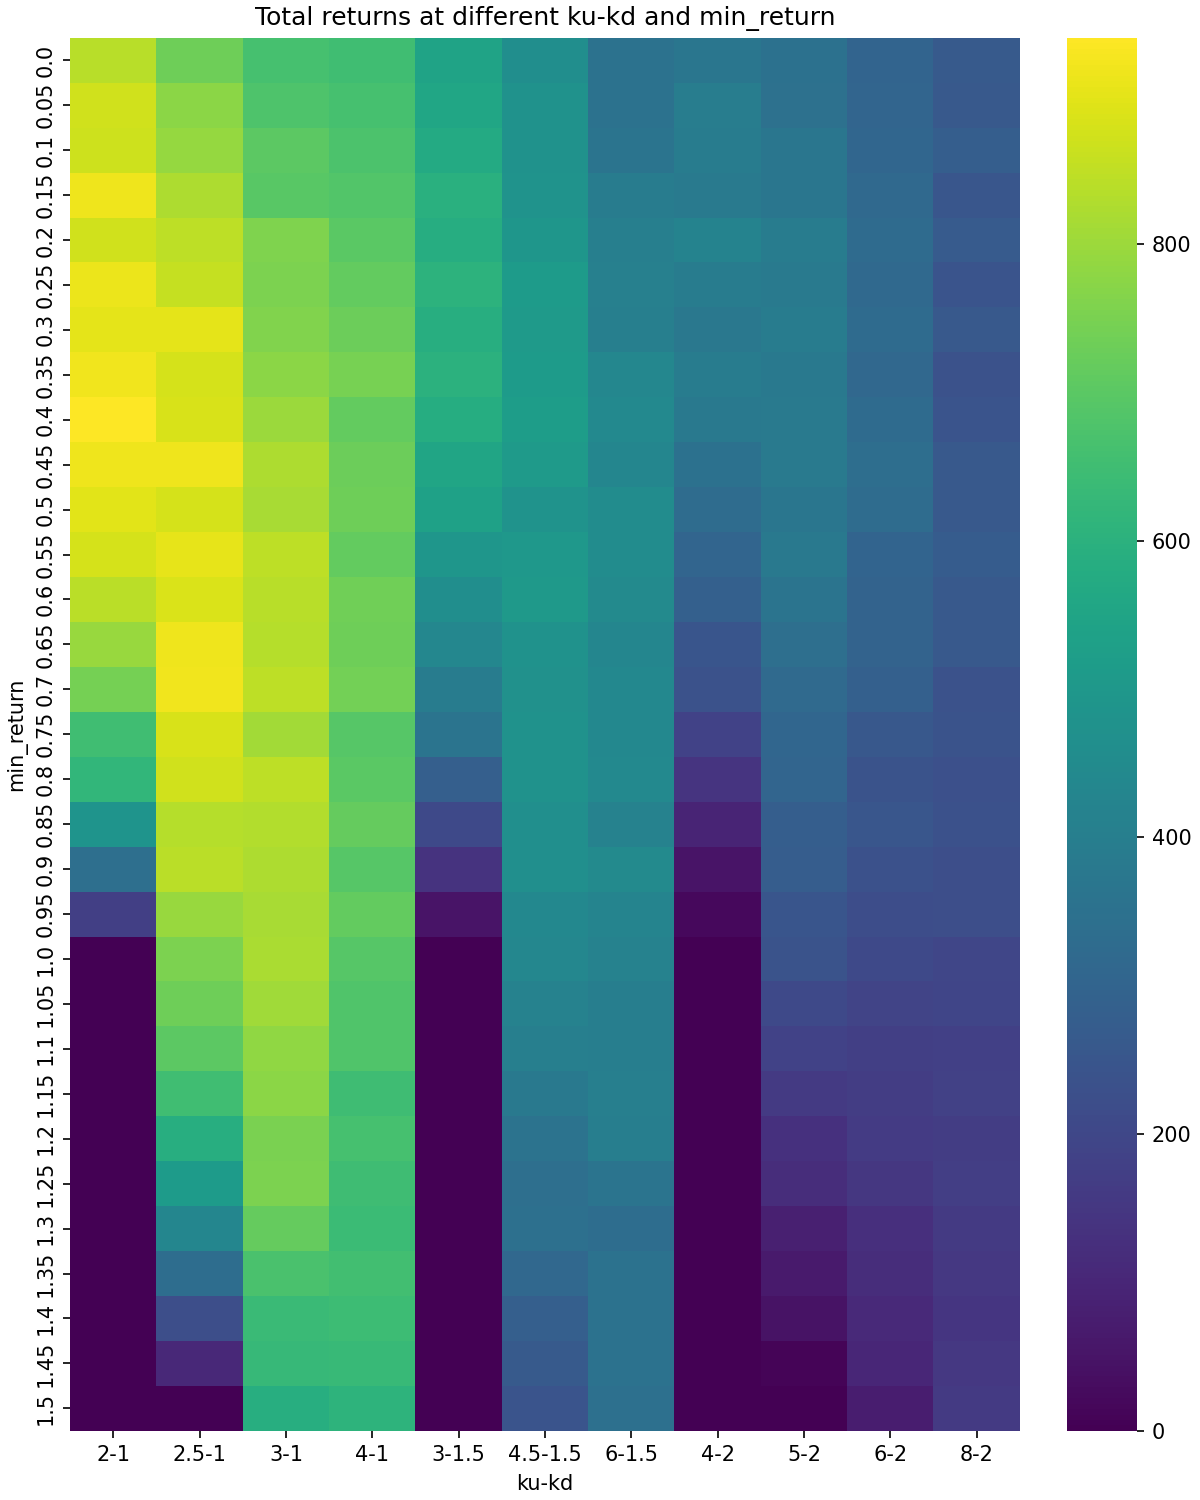

In [32]:
import matplotlib
matplotlib.use("Agg")  # off-screen
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display


fig, ax = plt.subplots(figsize=(8, 10), constrained_layout=True)
sns.heatmap(return_df, cmap="viridis", ax=ax)   # add annot=True if needed
ax.set_xlabel('ku-kd')
ax.set_ylabel('min_return')
ax.set_title('Total returns at different ku-kd and min_return')
fig.savefig(f"{DATA_DIR}/gru_ku-kd_vs_min-return_hold{hold}.png", dpi=150)
plt.close(fig)                            # important in Kaggle

display(Image(f"{DATA_DIR}/gru_ku-kd_vs_min-return_hold{hold}.png"))

In [49]:
#dropout optimization
f1 = {}
total_return = {}

for dropout in res:
    f1s = {}
    returns = {}
    for model in res[dropout]:
        f1s[model] = res[dropout][model]['val_metrics']['tp_f1']
        returns[model] = res[dropout][model]['trade_metrics']['total_return']
    f1[dropout] = f1s
    total_return[dropout] = returns

f1_df = pd.DataFrame(f1).sort_index(axis=1)
return_df = pd.DataFrame(total_return).sort_index(axis=1)

print(f1_df)
print(return_df)
# f1_df.to_csv('f1tp-dropout.csv')
# return_df.to_csv('return-dropout.csv')

            0.05      0.10      0.15      0.20      0.25      0.30      0.35
LSTM    0.501011  0.518561  0.501369  0.504138  0.490476  0.521554  0.534733
BiLSTM  0.542768  0.540308  0.534315  0.524559  0.538451  0.529062  0.536354
GRU     0.546466  0.585067  0.557870  0.561652  0.545455  0.544430  0.556387
              0.05        0.10        0.15        0.20        0.25  \
LSTM    633.380848  678.284488  633.901107  646.476593  652.601219   
BiLSTM  710.641329  708.074539  700.058375  688.359353  728.374269   
GRU     782.246855  808.648102  760.450153  783.681551  818.385775   

              0.30        0.35  
LSTM    643.868395  676.757938  
BiLSTM  701.261824  708.980009  
GRU     721.020778  784.739227  


In [141]:
df_val_price = df_val[['high', 'low', 'close', 'atr_14']+target].iloc[window_size-1:].reset_index(drop=True)
df_val_price.shape

(30640, 5)

In [33]:
import os
zip_path = "/kaggle/working/outputs.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
    print("Deleted:", zip_path)
else:
    print("Not found:", zip_path)



Deleted: /kaggle/working/outputs.zip


In [34]:
import os, zipfile

root = "/kaggle/working"
zip_path = os.path.join(root, "outputs.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for r, _, files in os.walk(root):
        for f in files:
            full = os.path.join(r, f)
            if os.path.abspath(full) == os.path.abspath(zip_path):  # skip self
                continue
            z.write(full, arcname=os.path.relpath(full, root))

In [147]:
import matplotlib.pyplot as plt

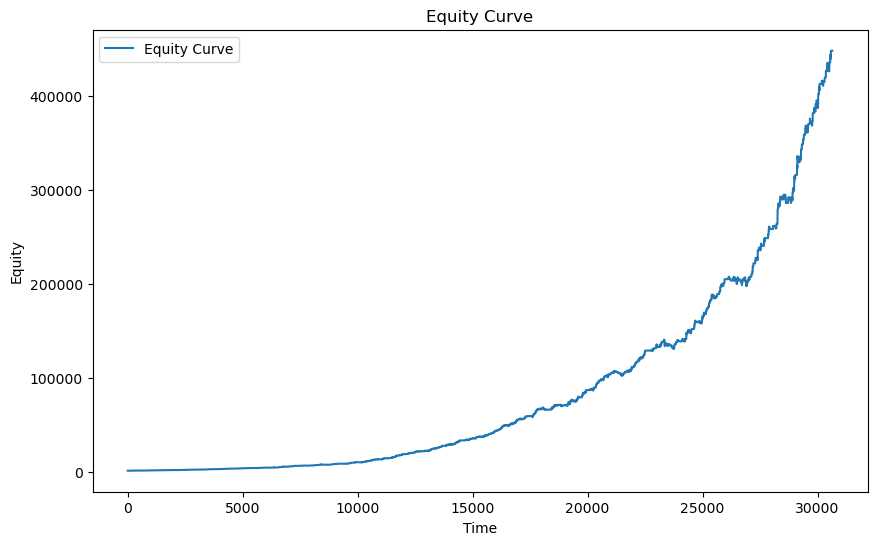

In [186]:
equity_curve = strategy.equity_curve
fig = plt.figure(figsize=(10, 6))
plt.plot(equity_curve, label='Equity Curve')
plt.xlabel('Time')
plt.ylabel('Equity')
plt.title('Equity Curve')
plt.legend()
plt.show()